In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [94]:
# Hanning Window Construction


window_size = 1024              # standard frame size
hop_size = 1024 * .5         # 75% overlap
hannWindow = [0] * window_size  # intializing array to hold window values


def hannWindowFunc(n): 
    return (np.sin(((np.pi * n) / window_size)))**2




for i in range(len(hannWindow)):
    hannWindow[i] = hannWindowFunc(i)


Text(0, 0.5, 'window value')

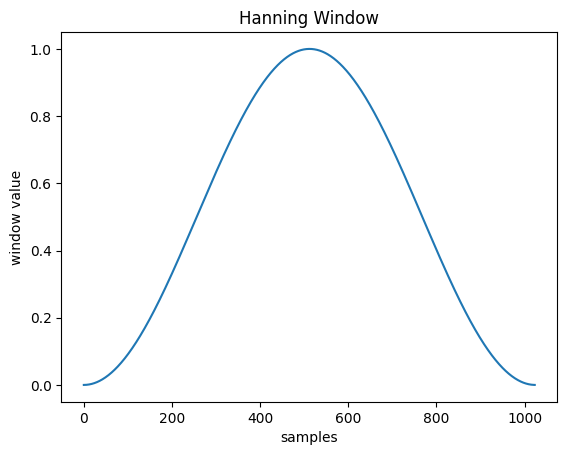

In [5]:
# Plot hann window
plt.plot(hannWindow)
plt.title("Hanning Window")
plt.xlabel("samples")
plt.ylabel("window value")


Text(0, 0.5, 'window value')

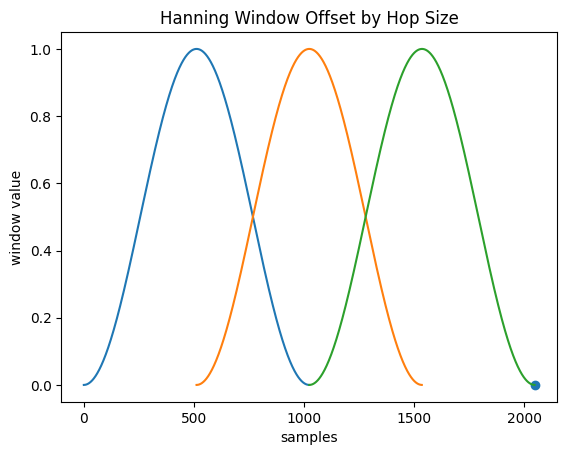

In [89]:

# Window Overlap Visualization 

#hop_size = window_size * .5
x = np.arange(window_size)

num_windows = 3


# draws first window, then second window
for i in range(num_windows): 
    offset = i * hop_size  
    plt.plot(x + offset, hannWindow)


cola_len = window_size + (num_windows - 1)*hop_size

plt.scatter(cola_len, 0)

#plt.scatter((num_offset * window_size) - (window_size - hop_size), 0)
plt.title("Hanning Window Offset by Hop Size")
plt.xlabel("samples")
plt.ylabel("window value")


Text(0, 0.5, 'window value')

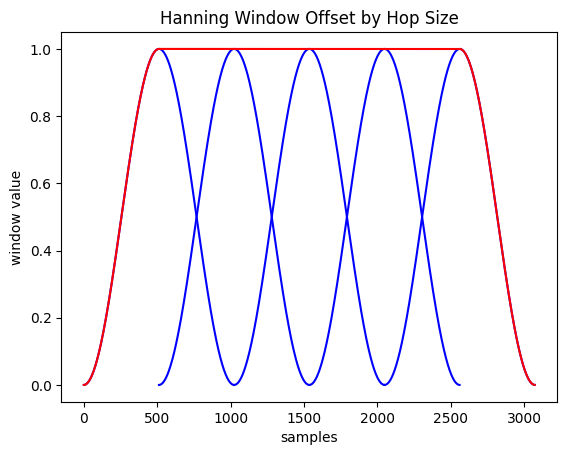

In [97]:
# Cola Property Visualization
num_windows = 5
cola_len = int(window_size + (num_windows - 1)*hop_size)
stop = cola_len - hop_size

cola_prop = np.zeros(cola_len)

def computeColaVal(): 
    cola_val = 0
    for i in range(num_windows): 
        offset = i * hop_size
        cola_val += hannWindow[i] + offset
    return cola_val

for i in range(cola_len): 
    if i < hop_size:
        cola_prop[i] = hannWindow[i]
    elif hop_size <= i <= stop: 
        cola_prop[i] += computeColaVal()
    else: 
        offset = num_windows
        winIdx = int(i - (num_windows-1)*hop_size)
        cola_prop[i] +=  hannWindow[winIdx]
        

for i in range(int(hop_size), int(cola_len - hop_size + 1)): 
     cola_prop[i] /= max(cola_prop)

for i in range(num_windows): 
    offset = i * hop_size  
    plt.plot(x + offset, hannWindow, 'blue')

#plt.scatter((num_offset * window_size) - (window_size - hop_size), 0)
plt.plot(cola_prop, 'red')
plt.title("Hanning Window Offset by Hop Size")
plt.xlabel("samples")
plt.ylabel("window value")



Text(0, 0.5, 'window value')

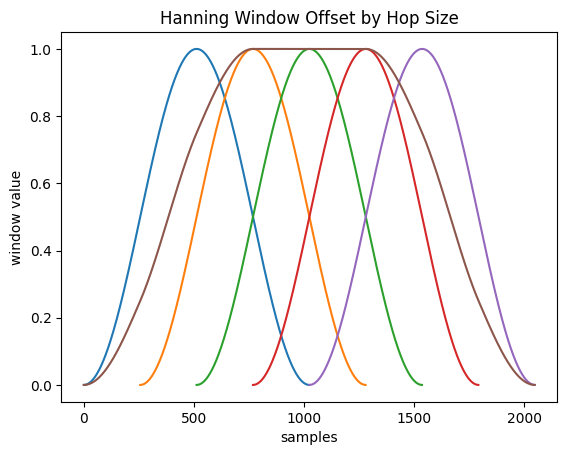

In [71]:
# COLA Property Visualization



hop_size = int(hop_size)

# COLA array length
cola_property = np.zeros(window_size + hop_size * (num_offset - 1), dtype=float)

m = np.arange(window_size, dtype=int)

for i in range(num_offset): 
    offset = i * hop_size
    idx = m + offset               
    cola_property[idx] += hannWindow

cola_property = cola_property / np.max(cola_property)

for i in range(num_offset): 
    offset = i * hop_size   
    plt.plot(x + offset, hannWindow) 
    

plt.plot(cola_property)
plt.title("Hanning Window Offset by Hop Size")
plt.xlabel("samples")
plt.ylabel("window value")